In [1]:
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')


In [2]:
# load the dataset
df = pd.read_csv('HRDataset_v14.csv')
pd.options.display.max_columns = None
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Position,State,Zip,DOB,Sex,MaritalDesc,CitizenDesc,HispanicLatino,RaceDesc,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,0,19,Production Technician I,MA,1960,7/10/1983,M,Single,US Citizen,No,White,7/5/2011,NaN,N/A-StillEmployed,Active,Production,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,1,27,Sr. DBA,MA,2148,5/5/1975,M,Married,US Citizen,No,White,3/30/2015,6/16/2016,career change,Voluntarily Terminated,IT/IS,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,1,20,Production Technician II,MA,1810,9/19/1988,F,Married,US Citizen,No,White,7/5/2011,9/24/2012,hours,Voluntarily Terminated,Production,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,0,19,Production Technician I,MA,1886,9/27/1988,F,Married,US Citizen,No,White,1/7/2008,NaN,N/A-StillEmployed,Active,Production,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,1,19,Production Technician I,MA,2169,9/8/1989,F,Divorced,US Citizen,No,White,7/11/2011,9/6/2016,return to school,Voluntarily Terminated,Production,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    str    
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    str    
 13  State                       311 non-null    st

In [4]:
df.isnull().sum()

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

In [5]:
df[df.ManagerID.isnull()][['ManagerID', "ManagerName", 'Department']]

,ManagerID,ManagerName,Department
19,NaN,Webster Butler,Production
30,NaN,Webster Butler,Production
44,NaN,Webster Butler,Production
88,NaN,Webster Butler,Production
135,NaN,Webster Butler,Production
177,NaN,Webster Butler,Production
232,NaN,Webster Butler,Production
251,NaN,Webster Butler,Production


In [6]:
df[df.ManagerName== 'Webster Butler'][['ManagerID', "ManagerName", 'Department']]

,ManagerID,ManagerName,Department
4,39.0,Webster Butler,Production
19,NaN,Webster Butler,Production
30,NaN,Webster Butler,Production
44,NaN,Webster Butler,Production
65,39.0,Webster Butler,Production
88,NaN,Webster Butler,Production
89,39.0,Webster Butler,Production
105,39.0,Webster Butler,Production
124,39.0,Webster Butler,Production
135,NaN,Webster Butler,Production


In [13]:
df['ManagerID'] = df['ManagerID'].fillna(39)

In [14]:
df['ManagerID'].isna().sum()

np.int64(0)

In [18]:
df.ManagerID = df.ManagerID.astype('int') 


In [19]:

date_columns = ['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']
df[date_columns].dtypes

DOB                           str
DateofHire                    str
DateofTermination             str
LastPerformanceReview_Date    str
dtype: object

In [20]:
# I changed the date colunms data type to datecolumns
for i in date_columns:
    df[i] = df[i].astype('datetime64[ns]')

In [21]:
# Rearrange and format
df['Employee_Name'] = (df['Employee_Name'].str.split(',', expand = True).iloc[:,1] 
                    + ' '
                    + df['Employee_Name'].str.split(',', expand = True).iloc[:,0])

In [22]:
# Dropped redundant columns
df.drop(columns = ['MarriedID','MaritalStatusID', 'GenderID', 
                   'Termd', 'PerfScoreID', 'EmpStatusID',
                   'PositionID',], inplace = True)


In [23]:
 #reorder of columns
cols_reorder = ['EmpID', 'Employee_Name','Sex', 'MaritalDesc', 'DeptID',
                'FromDiversityJobFairID', 'Salary',
                'Position', 'State', 'Zip', 'DOB', 
                'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire',
                'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department',
                'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore',
                'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount',
                'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences'
       ]

In [24]:
df = df[cols_reorder]
df.head()

,EmpID,Employee_Name,Sex,MaritalDesc,DeptID,FromDiversityJobFairID,Salary,Position,State,Zip,DOB,CitizenDesc,HispanicLatino,RaceDesc,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,10026,Wilson K Adinolfi,M,Single,5,0,62506,Production Technician I,MA,1960,1983-07-10,US Citizen,No,White,2011-07-05,NaT,N/A-StillEmployed,Active,Production,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,10084,Karthikeyan Ait Sidi,M,Married,3,0,104437,Sr. DBA,MA,2148,1975-05-05,US Citizen,No,White,2015-03-30,2016-06-16,career change,Voluntarily Terminated,IT/IS,Simon Roup,4,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,10196,Sarah Akinkuolie,F,Married,5,0,64955,Production Technician II,MA,1810,1988-09-19,US Citizen,No,White,2011-07-05,2012-09-24,hours,Voluntarily Terminated,Production,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,10088,Trina Alagbe,F,Married,5,0,64991,Production Technician I,MA,1886,1988-09-27,US Citizen,No,White,2008-01-07,NaT,N/A-StillEmployed,Active,Production,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,10069,Carol Anderson,F,Divorced,5,0,50825,Production Technician I,MA,2169,1989-09-08,US Citizen,No,White,2011-07-11,2016-09-06,return to school,Voluntarily Terminated,Production,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2


In [25]:
# saving cleaned data
df.to_csv('HR_Employee_Cleaned_Data.csv', index = False)

In [ ]:
# E

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set()

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   EmpID                       311 non-null    int64         
 1   Employee_Name               311 non-null    str           
 2   Sex                         311 non-null    str           
 3   MaritalDesc                 311 non-null    str           
 4   DeptID                      311 non-null    int64         
 5   FromDiversityJobFairID      311 non-null    int64         
 6   Salary                      311 non-null    int64         
 7   Position                    311 non-null    str           
 8   State                       311 non-null    str           
 9   Zip                         311 non-null    int64         
 10  DOB                         311 non-null    datetime64[ns]
 11  CitizenDesc                 311 non-null    str           
 12  Hispa

In [29]:
date_columns = ['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']
# I changed the date colunms data type to datecolumns
for i in date_columns:
    df[i] = pd.to_datetime(df[i])

# changed the data type of salary column to float from object type
df['Salary'] = df['Salary'].astype('float')

In [30]:
# summary statistics
df.describe(include = 'all')

,EmpID,Employee_Name,Sex,MaritalDesc,DeptID,FromDiversityJobFairID,Salary,Position,State,Zip,DOB,CitizenDesc,HispanicLatino,RaceDesc,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
count,311.000000,311,311,311,311.000000,311.000000,311.000000,311,311,311.000000,311,311,311,311,311,104,311,311,311,311,311.000000,311,311,311.000000,311.000000,311.000000,311,311.000000,311.000000
unique,NaN,311,2,5,NaN,NaN,NaN,32,28,NaN,NaN,3,4,6,NaN,NaN,18,3,6,21,NaN,9,4,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Wilson K Adinolfi,F,Single,NaN,NaN,NaN,Production Technician I,MA,NaN,NaN,US Citizen,No,White,NaN,NaN,N/A-StillEmployed,Active,Production,Michael Albert,NaN,Indeed,Fully Meets,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,176,137,NaN,NaN,NaN,137,276,NaN,NaN,295,282,187,NaN,NaN,207,207,209,22,NaN,87,243,NaN,NaN,NaN,NaN,NaN,NaN
mean,10156.000000,NaN,NaN,NaN,4.610932,0.093248,69020.684887,NaN,NaN,6555.482315,1979-02-06 09:48:02.315112544,NaN,NaN,NaN,2013-02-03 22:50:32.797427712,2015-06-14 11:46:09.230769152,NaN,NaN,NaN,NaN,15.199357,NaN,NaN,4.110000,3.890675,1.218650,2017-09-10 21:17:56.527331072,0.414791,10.237942
min,10001.000000,NaN,NaN,NaN,1.000000,0.000000,45046.000000,NaN,NaN,1013.000000,1951-01-02 00:00:00,NaN,NaN,NaN,2006-01-09 00:00:00,2010-08-30 00:00:00,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.120000,1.000000,0.000000,2010-07-14 00:00:00,0.000000,1.000000
25%,10078.500000,NaN,NaN,NaN,5.000000,0.000000,55501.500000,NaN,NaN,1901.500000,1973-12-03 00:00:00,NaN,NaN,NaN,2011-07-11 00:00:00,2014-01-10 12:00:00,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,3.690000,3.000000,0.000000,2016-03-19 12:00:00,0.000000,5.000000
50%,10156.000000,NaN,NaN,NaN,5.000000,0.000000,62810.000000,NaN,NaN,2132.000000,1980-09-30 00:00:00,NaN,NaN,NaN,2013-02-18 00:00:00,2015-09-22 00:00:00,NaN,NaN,NaN,NaN,16.000000,NaN,NaN,4.280000,4.000000,0.000000,2019-01-16 00:00:00,0.000000,10.000000
75%,10233.500000,NaN,NaN,NaN,5.000000,0.000000,72036.000000,NaN,NaN,2355.000000,1986-05-29 12:00:00,NaN,NaN,NaN,2014-09-23 12:00:00,2016-09-08 06:00:00,NaN,NaN,NaN,NaN,19.500000,NaN,NaN,4.700000,5.000000,0.000000,2019-02-04 00:00:00,0.000000,15.000000
max,10311.000000,NaN,NaN,NaN,6.000000,1.000000,250000.000000,NaN,NaN,98052.000000,1992-08-17 00:00:00,NaN,NaN,NaN,2018-07-09 00:00:00,2018-11-10 00:00:00,NaN,NaN,NaN,NaN,39.000000,NaN,NaN,5.000000,5.000000,8.000000,2019-02-28 00:00:00,6.000000,20.000000


In [31]:
# Frequency of categorical variables
df.Sex.value_counts()

Sex
F     176
M     135
Name: count, dtype: int64

In [32]:
df.MaritalDesc.value_counts()

MaritalDesc
Single       137
Married      124
Divorced      30
Separated     12
Widowed        8
Name: count, dtype: int64

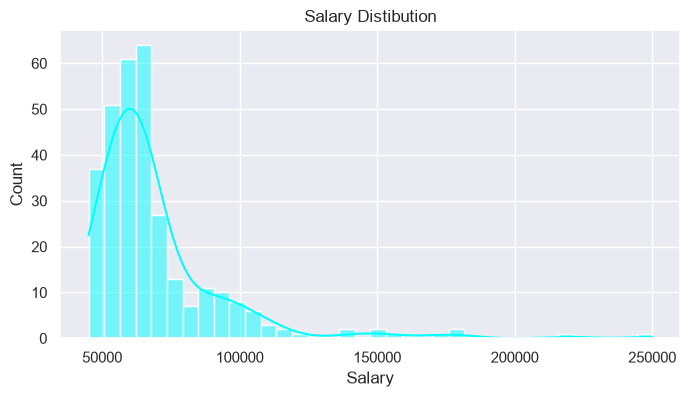

In [33]:
plt.figure(figsize = (8, 4))

sns.histplot(df.Salary, kde=True, color = 'cyan')
plt.title('Salary Distibution')
plt.show()

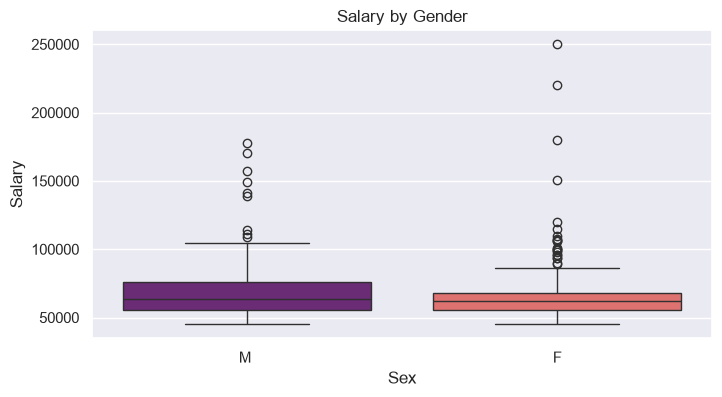

In [34]:
plt.figure(figsize = (8, 4))

sns.boxplot(x = 'Sex', y = 'Salary', data=df, palette='magma')
plt.title('Salary by Gender')
plt.show()

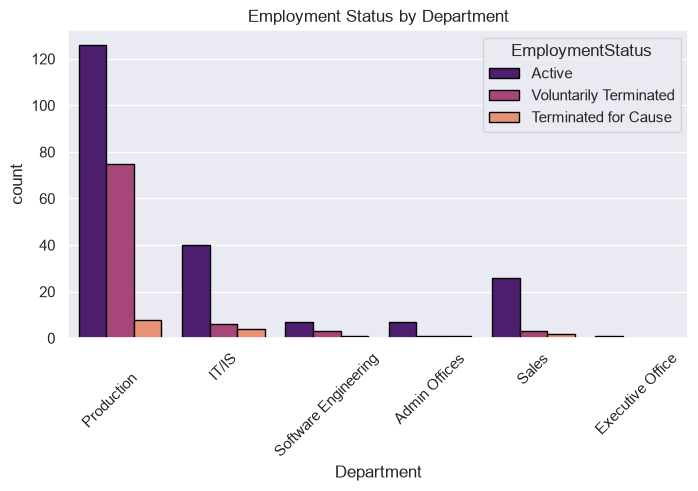

In [35]:
plt.figure(figsize = (8, 4))

sns.countplot(x = 'Department', hue = 'EmploymentStatus', data=df, palette='magma', edgecolor='black')
plt.title('Employment Status by Department')
plt.xticks(rotation=45)
plt.show()

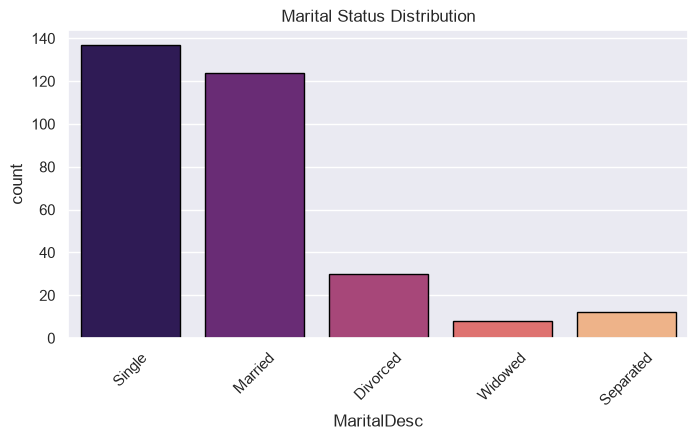

In [36]:
plt.figure(figsize = (8, 4))

sns.countplot(x = 'MaritalDesc', data=df, palette='magma', edgecolor='black')
plt.title('Marital Status Distribution')
plt.xticks(rotation=45)
plt.show()

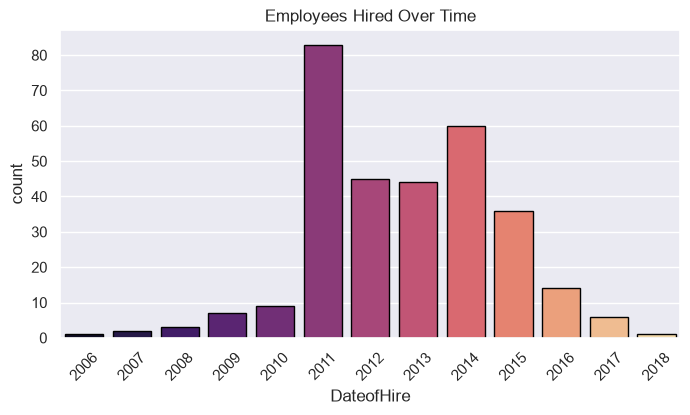

In [37]:
plt.figure(figsize = (8, 4))

sns.countplot(x = df['DateofHire'].dt.year, palette='magma', edgecolor='black')
plt.title('Employees Hired Over Time')
plt.xticks(rotation=45)
plt.show()

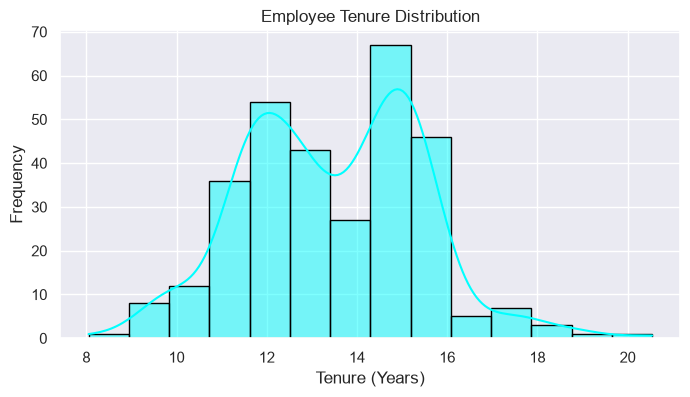

In [38]:
df['Tenure'] = (pd.to_datetime('today') - df['DateofHire']).dt.days / 365.25
plt.figure(figsize=(8, 4))
sns.histplot(df['Tenure'], color = 'cyan', kde=True, edgecolor = 'black')
plt.title('Employee Tenure Distribution')
plt.xlabel('Tenure (Years)')
plt.ylabel('Frequency')
plt.show()


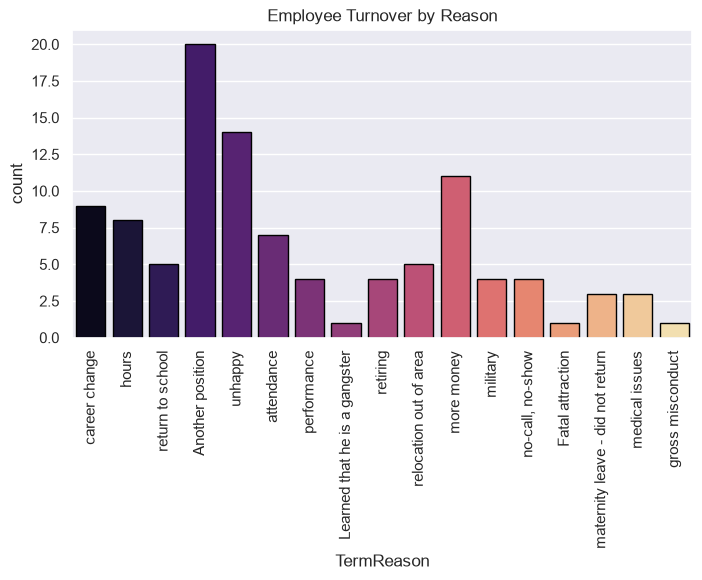

In [39]:
plt.figure(figsize = (8, 4))

sns.countplot(x = 'TermReason', data = df[df.TermReason != 'N/A-StillEmployed'], palette='magma', edgecolor='black')
plt.title('Employee Turnover by Reason')
plt.xticks(rotation=90)
plt.show()

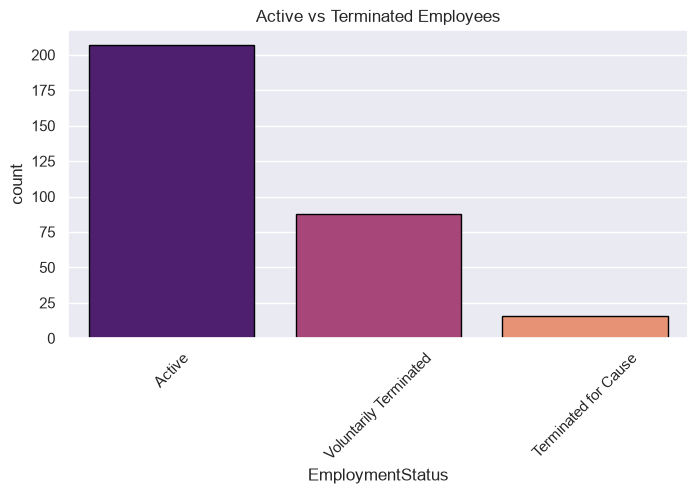

In [40]:
plt.figure(figsize = (8, 4))

sns.countplot(x = 'EmploymentStatus', data = df, palette='magma', edgecolor='black')
plt.title('Active vs Terminated Employees')
plt.xticks(rotation=45)
plt.show()

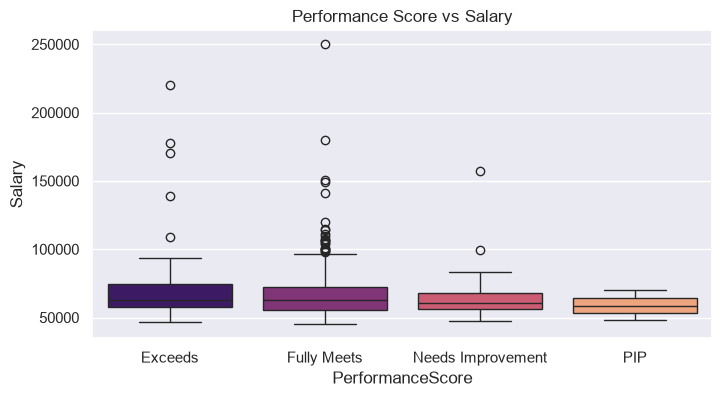

In [41]:
plt.figure(figsize = (8, 4))

sns.boxplot(x = 'PerformanceScore', y = 'Salary', data=df, palette='magma')
plt.title('Performance Score vs Salary')
plt.show()

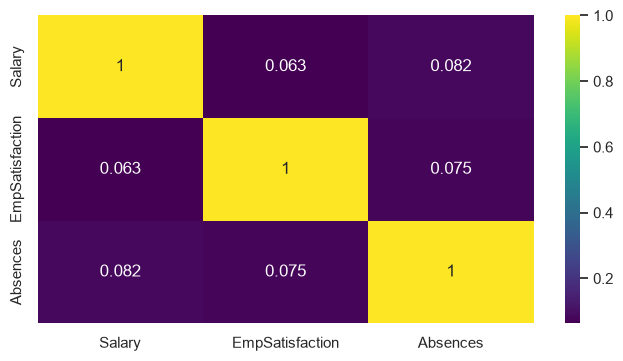

In [42]:
plt.figure(figsize = (8, 4))
correlation = df[['Salary', 'EmpSatisfaction', 'Absences']].corr()
sns.heatmap(correlation, annot=True, cmap='viridis')
plt.show()

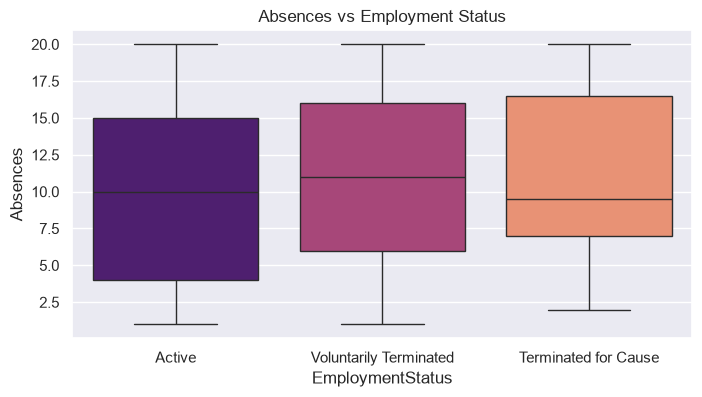

In [43]:
plt.figure(figsize = (8, 4))

sns.boxplot(x = 'EmploymentStatus', y = 'Absences', data=df, palette='magma')
plt.title('Absences vs Employment Status')
plt.show()

<Figure size 800x500 with 0 Axes>

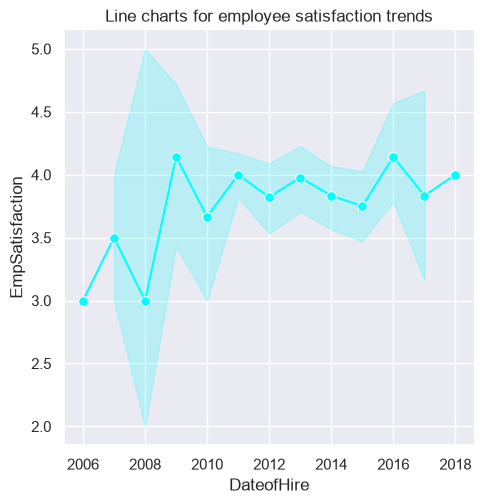

In [44]:
plt.figure(figsize = (8, 5))

sns.relplot(x = df['DateofHire'].dt.year, y = 'EmpSatisfaction', data=df, 
            kind = 'line', marker='o',color = 'cyan', markersize=7)
plt.title('Line charts for employee satisfaction trends')
plt.show()

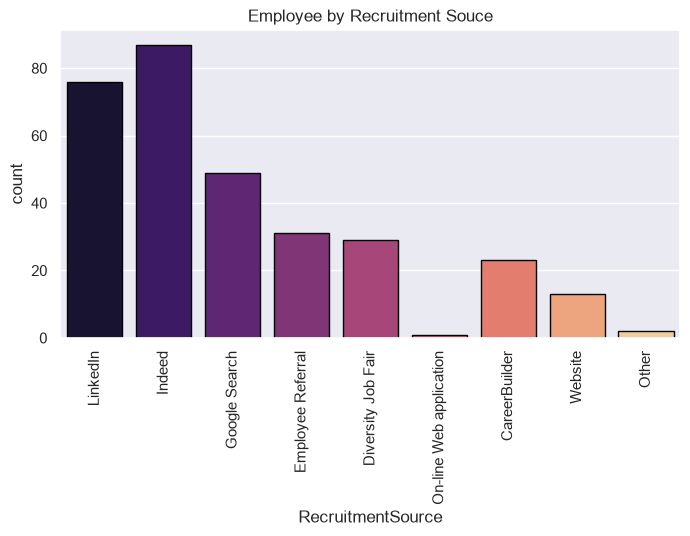

In [52]:
plt.figure(figsize = (8, 4))

sns.countplot(x = 'RecruitmentSource', data = df, palette='magma', edgecolor='black')
plt.title('Employee by Recruitment Souce')
plt.xticks(rotation=90)
plt.show()

In [64]:
pip install sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import pandas as pd

df = pd.read_csv("HR_Employee_Cleaned_Data.csv")

In [68]:
print(df.columns.tolist())

['EmpID', 'Employee_Name', 'Sex', 'MaritalDesc', 'DeptID', 'FromDiversityJobFairID', 'Salary', 'Position', 'State', 'Zip', 'DOB', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']


In [70]:
# Rename columns
df.columns = [
    "emp_id",
    "employee_name",
    "sex",
    "marital_desc",
    "dept_id",
    "from_diversity_job_fair_id",
    "salary",
    "position",
    "state",
    "zip",
    "dob",
    "citizen_desc",
    "hispanic_latino",
    "race_desc",
    "date_of_hire",
    "date_of_termination",
    "term_reason",
    "employment_status",
    "department",
    "manager_name",
    "manager_id",
    "recruitment_source",
    "performance_score",
    "engagement_survey",
    "emp_satisfaction",
    "special_projects_count",
    "last_performance_review_date",
    "days_late_last_30",
    "absences"
]
df

,emp_id,employee_name,sex,marital_desc,dept_id,from_diversity_job_fair_id,salary,position,state,zip,dob,citizen_desc,hispanic_latino,race_desc,date_of_hire,date_of_termination,term_reason,employment_status,department,manager_name,manager_id,recruitment_source,performance_score,engagement_survey,emp_satisfaction,special_projects_count,last_performance_review_date,days_late_last_30,absences
0,10026,Wilson K Adinolfi,M,Single,5,0,62506,Production Technician I,MA,1960,1983-07-10,US Citizen,No,White,2011-07-05,NaN,N/A-StillEmployed,Active,Production,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,10084,Karthikeyan Ait Sidi,M,Married,3,0,104437,Sr. DBA,MA,2148,1975-05-05,US Citizen,No,White,2015-03-30,2016-06-16,career change,Voluntarily Terminated,IT/IS,Simon Roup,4,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,10196,Sarah Akinkuolie,F,Married,5,0,64955,Production Technician II,MA,1810,1988-09-19,US Citizen,No,White,2011-07-05,2012-09-24,hours,Voluntarily Terminated,Production,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,10088,Trina Alagbe,F,Married,5,0,64991,Production Technician I,MA,1886,1988-09-27,US Citizen,No,White,2008-01-07,NaN,N/A-StillEmployed,Active,Production,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,10069,Carol Anderson,F,Divorced,5,0,50825,Production Technician I,MA,2169,1989-09-08,US Citizen,No,White,2011-07-11,2016-09-06,return to school,Voluntarily Terminated,Production,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,10135,Jason Woodson,M,Single,5,0,65893,Production Technician II,MA,1810,1985-05-11,US Citizen,No,White,2014-07-07,NaN,N/A-StillEmployed,Active,Production,Kissy Sullivan,20,LinkedIn,Fully Meets,4.07,4,0,2019-02-28,0,13
307,10301,Catherine Ybarra,F,Single,5,0,48513,Production Technician I,MA,2458,1982-05-04,US Citizen,No,Asian,2008-09-02,2015-09-29,Another position,Voluntarily Terminated,Production,Brannon Miller,12,Google Search,PIP,3.20,2,0,2015-09-02,5,4
308,10010,Jennifer Zamora,F,Single,3,0,220450,CIO,MA,2067,1979-08-30,US Citizen,No,White,2010-04-10,NaN,N/A-StillEmployed,Active,IT/IS,Janet King,2,Employee Referral,Exceeds,4.60,5,6,2019-02-21,0,16
309,10043,Julia Zhou,F,Single,3,0,89292,Data Analyst,MA,2148,1979-02-24,US Citizen,No,White,2015-03-30,NaN,N/A-StillEmployed,Active,IT/IS,Simon Roup,4,Employee Referral,Fully Meets,5.00,3,5,2019-02-01,0,11


In [74]:
date_columns = [
    "dob",
    "date_of_hire",
    "date_of_termination",
    "last_performance_review_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [75]:
from urllib.parse import quote_plus
from sqlalchemy import create_engine

username = "postgres"
password = quote_plus("Root@1234")   
host = "localhost"
port = "5432"
database = "hr_analytics"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

In [76]:
table_name = "hr_employee"

df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'hr_employee' in database 'hr_analytics'.


In [77]:
print(df.columns.tolist())

['emp_id', 'employee_name', 'sex', 'marital_desc', 'dept_id', 'from_diversity_job_fair_id', 'salary', 'position', 'state', 'zip', 'dob', 'citizen_desc', 'hispanic_latino', 'race_desc', 'date_of_hire', 'date_of_termination', 'term_reason', 'employment_status', 'department', 'manager_name', 'manager_id', 'recruitment_source', 'performance_score', 'engagement_survey', 'emp_satisfaction', 'special_projects_count', 'last_performance_review_date', 'days_late_last_30', 'absences']
